# Real‑Time Traffic Congestion Prediction Using MongoDB and Machine Learning
**Module:** 6CS030 Big Data  
**Students:** Aman Rauniyar(B), Pujan Raj Poudyal
**ID:2408033**  
**Target variable:** Congestion Level (High, Medium, Low)

This notebook is the technical code appendix for the Big Data coursework. It demonstrates data cleaning (MongoDB), feature engineering, exploratory data analysis, machine learning model training, evaluation, and a simple real‑time prediction workflow for traffic congestion in Kathmandu Valley.

IMPORT LIBRARIES

In [59]:
# REAL-TIME TRAFFIC CONGESTION PREDICTION
# USING MACHINE LEARNING AND MONGODB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


 UPLOAD DATASET

In [19]:
from google.colab import files

print("Upload your cleaned traffic dataset CSV file")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(f"\nDataset Loaded Successfully")
print(f"Total Records: {len(df)}")

df.head()


Upload your cleaned traffic dataset CSV file


Saving cleaned_traffic_15k.csv to cleaned_traffic_15k (3).csv

Dataset Loaded Successfully
Total Records: 15000


,Date,Time,Location,Vehicle_Count,Average_Speed,Congestion_Level,Weather
0,2025-01-16,11:15,Maharajgunj,812,37.5,Low,Rain
1,2025-02-28,13:15,Baneshwor,96,37.6,Medium,Cloudy
2,2025-04-24,15:15,Lalitpur,799,33.2,Low,Fog
3,2025-02-06,8:00,Bhaktapur,48,34.7,High,Rain
4,2025-01-18,14:15,Chabahil,102,34.7,Low,Rain


DATASET OVERVIEW

In [58]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Records:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nCongestion Level Distribution:")
print(df['Congestion_Level'].value_counts())



Dataset Shape:
(14973, 13)

Column Names:
Index(['Date', 'Time', 'Location', 'Vehicle_Count', 'Average_Speed',
       'Congestion_Level', 'Weather', 'Hour', 'DayOfWeek', 'IsWeekend',
       'Month', 'Location_Code', 'Weather_Code'],
      dtype='object')

First 5 Records:
        Date   Time     Location  Vehicle_Count  Average_Speed  \
0 2025-01-16  11:15  Maharajgunj            812           37.5   
1 2025-02-28  13:15    Baneshwor             96           37.6   
2 2025-04-24  15:15     Lalitpur            799           33.2   
3 2025-02-06   8:00    Bhaktapur             48           34.7   
4 2025-01-18  14:15     Chabahil            102           34.7   

  Congestion_Level Weather  Hour  DayOfWeek  IsWeekend  Month  Location_Code  \
0              Low    Rain    11          3          0      1              6   
1           Medium  Cloudy    13          4          0      2              0   
2              Low     Fog    15          3          0      4              5   
3        

 DATA CLEANING

In [39]:
# Remove invalid vehicle counts
df = df[df['Vehicle_Count'] >= 0]

# Remove unrealistic speed values
df = df[df['Average_Speed'] <= 120]

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset After Cleaning:")
print(df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())


Dataset After Cleaning:
(14973, 13)

Remaining Missing Values:
Date                0
Time                0
Location            0
Vehicle_Count       0
Average_Speed       0
Congestion_Level    0
Weather             0
Hour                0
DayOfWeek           0
IsWeekend           0
Month               0
Location_Code       0
Weather_Code        0
dtype: int64


FEATURE ENGINEERING

In [40]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Extract Time Features
df['Hour'] = pd.to_datetime(
    df['Time'],
    errors='coerce'
).dt.hour

df['Hour'] = df['Hour'].fillna(12).astype(int)

df['DayOfWeek'] = df['Date'].dt.dayofweek

df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

df['Month'] = df['Date'].dt.month

# Label Encoding
le_location = LabelEncoder()
le_weather = LabelEncoder()
le_target = LabelEncoder()

df['Location_Code'] = le_location.fit_transform(
    df['Location']
)

df['Weather_Code'] = le_weather.fit_transform(
    df['Weather']
)

# Target Variable
y = le_target.fit_transform(
    df['Congestion_Level']
)

# FINAL FEATURES
# Leakage features removed intentionally
feature_cols = [
    'Location_Code',
    'Weather_Code',
    'Vehicle_Count',
    'Average_Speed',
    'Hour',
    'DayOfWeek',
    'IsWeekend',
    'Month'
]

X = df[feature_cols]

print("\nFeatures Used:")
print(feature_cols)

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Classes:")
print(le_target.classes_)



Features Used:
['Location_Code', 'Weather_Code', 'Vehicle_Count', 'Average_Speed', 'Hour', 'DayOfWeek', 'IsWeekend', 'Month']

Feature Matrix Shape:
(14973, 8)

Target Classes:
['High' 'Low' 'Medium']


EXPLORATORY DATA ANALYSIS

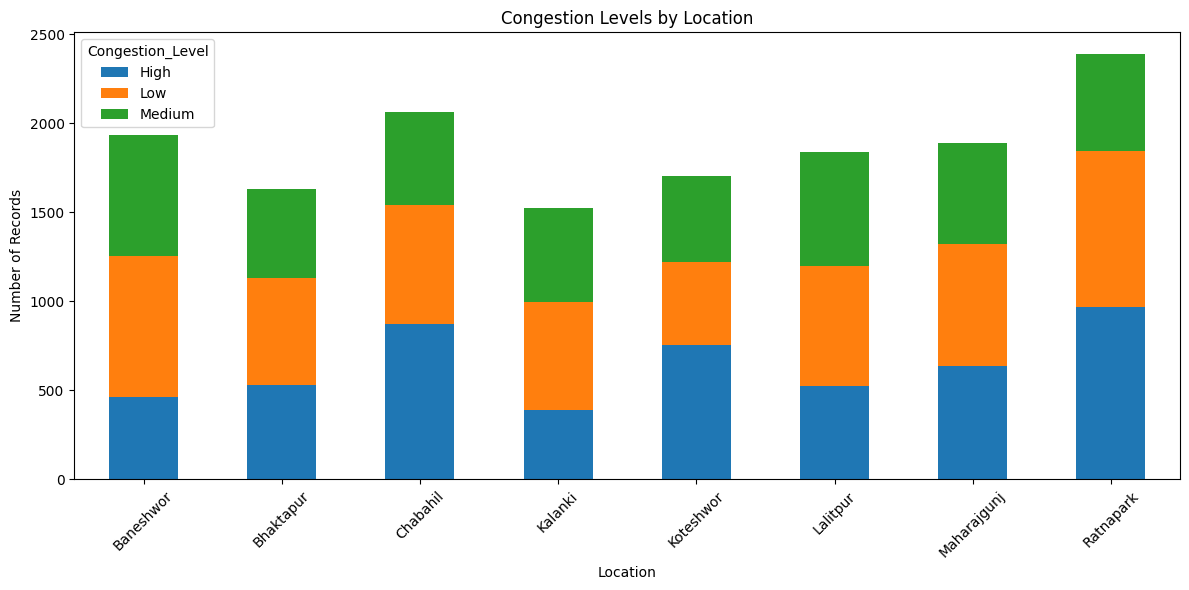

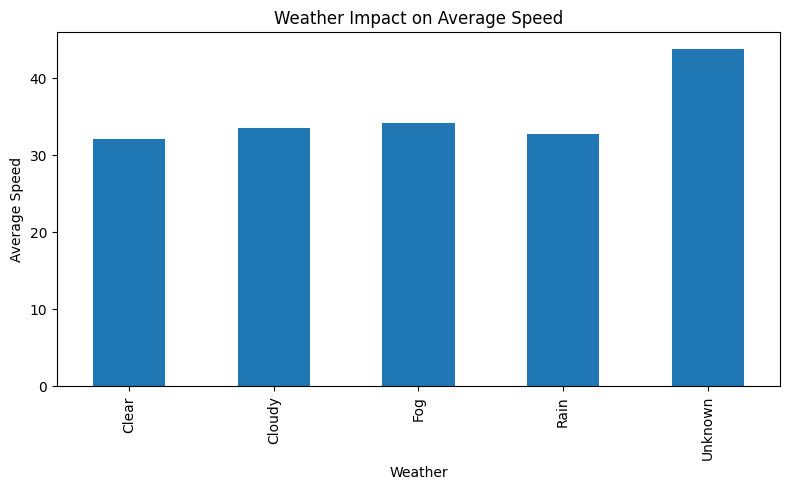

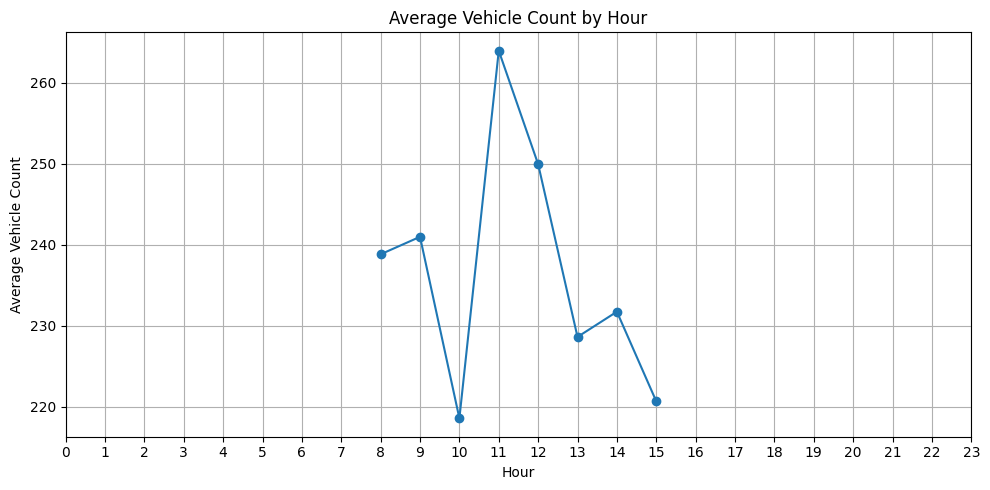

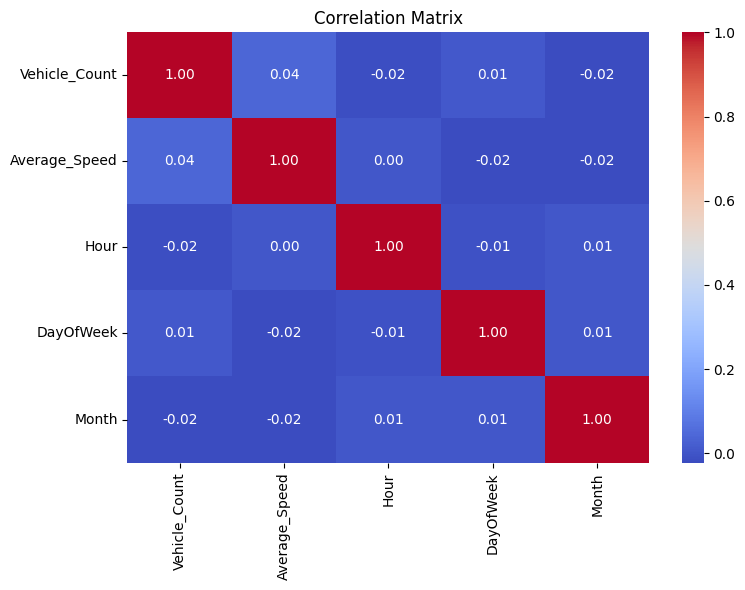

In [41]:
# ------------------------------------------------------------
# 1. Congestion by Location
# ------------------------------------------------------------

congestion_counts = pd.crosstab(
    df['Location'],
    df['Congestion_Level']
)

congestion_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Congestion Levels by Location')
plt.xlabel('Location')
plt.ylabel('Number of Records')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 2. Weather Impact on Speed
# ------------------------------------------------------------

weather_speed = df.groupby(
    'Weather'
)['Average_Speed'].mean()

plt.figure(figsize=(8,5))

weather_speed.plot(kind='bar')

plt.title('Weather Impact on Average Speed')

plt.xlabel('Weather')
plt.ylabel('Average Speed')

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 3. Hourly Vehicle Count
# ------------------------------------------------------------

hourly_traffic = df.groupby(
    'Hour'
)['Vehicle_Count'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker='o'
)

plt.title('Average Vehicle Count by Hour')

plt.xlabel('Hour')
plt.ylabel('Average Vehicle Count')

plt.xticks(range(0,24))

plt.grid(True)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 4. Correlation Heatmap
# ------------------------------------------------------------

numeric_cols = [
    'Vehicle_Count',
    'Average_Speed',
    'Hour',
    'DayOfWeek',
    'Month'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()



TRAIN TEST SPLIT

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])




Training Samples: 11978
Testing Samples: 2995


MODEL TRAINING

In [44]:
models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy*100:.2f}%")


Logistic Regression Accuracy: 37.63%
Decision Tree Accuracy: 67.25%
Random Forest Accuracy: 88.65%
Gradient Boosting Accuracy: 64.04%


BEST MODEL SELECTION

In [57]:
best_model_name = max(
    results,
    key=results.get
)

best_model = models[best_model_name]

print("")
print("BEST MODEL")
print("")

print(
    f"\nBest Model: {best_model_name}"
)

print(
    f"Accuracy: {results[best_model_name]*100:.2f}%"
)


BEST MODEL


Best Model: Random Forest
Accuracy: 88.65%


DETAILED EVALUATION



In [47]:
# Predictions
y_pred_best = best_model.predict(X_test)

# Accuracy
final_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print(
    f"\nFinal Accuracy: {final_accuracy*100:.2f}%"
)

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=le_target.classes_
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nConfusion Matrix:\n")
print(cm)


Final Accuracy: 88.65%

Classification Report:

              precision    recall  f1-score   support

        High       0.88      0.90      0.89      1029
         Low       0.87      0.92      0.90      1072
      Medium       0.92      0.82      0.87       894

    accuracy                           0.89      2995
   macro avg       0.89      0.88      0.89      2995
weighted avg       0.89      0.89      0.89      2995


Confusion Matrix:

[[930  66  33]
 [ 47 991  34]
 [ 77  83 734]]


CROSS VALIDATION

In [48]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Scores:")
print(cv_scores)

print(
    f"\nAverage Cross Validation Accuracy: "
    f"{cv_scores.mean()*100:.2f}%"
)


Cross Validation Scores:
[0.90050083 0.88213689 0.89716194 0.88911156 0.88476954]

Average Cross Validation Accuracy: 89.07%


CONFUSION MATRIX HEATMAP

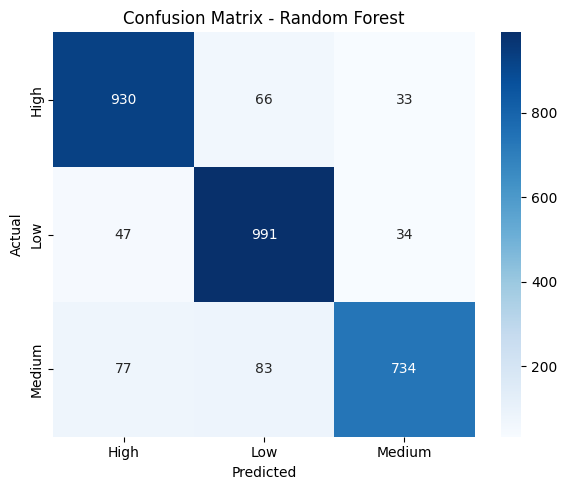

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.show()


FEATURE IMPORTANCE


Feature Importance:

         Feature  Importance
2  Vehicle_Count    0.241043
4           Hour    0.178446
3  Average_Speed    0.172927
0  Location_Code    0.151336
7          Month    0.112063
1   Weather_Code    0.096817
5      DayOfWeek    0.038790
6      IsWeekend    0.008578


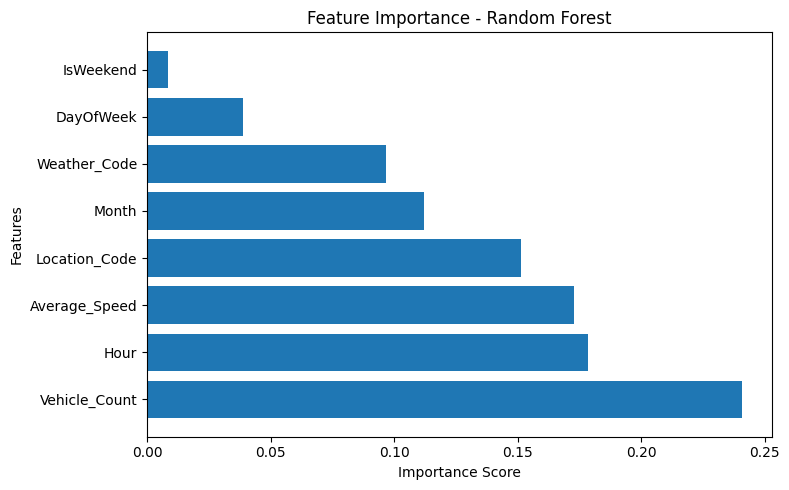

In [50]:
if hasattr(best_model, 'feature_importances_'):

    importance_df = pd.DataFrame({

        'Feature': feature_cols,

        'Importance':
        best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    print("\nFeature Importance:\n")

    print(importance_df)

    # Plot
    plt.figure(figsize=(8,5))

    plt.barh(
        importance_df['Feature'],
        importance_df['Importance']
    )

    plt.xlabel('Importance Score')
    plt.ylabel('Features')

    plt.title(
        f'Feature Importance - {best_model_name}'
    )

    plt.tight_layout()

    plt.show()


MODEL COMPARISON GRAPH

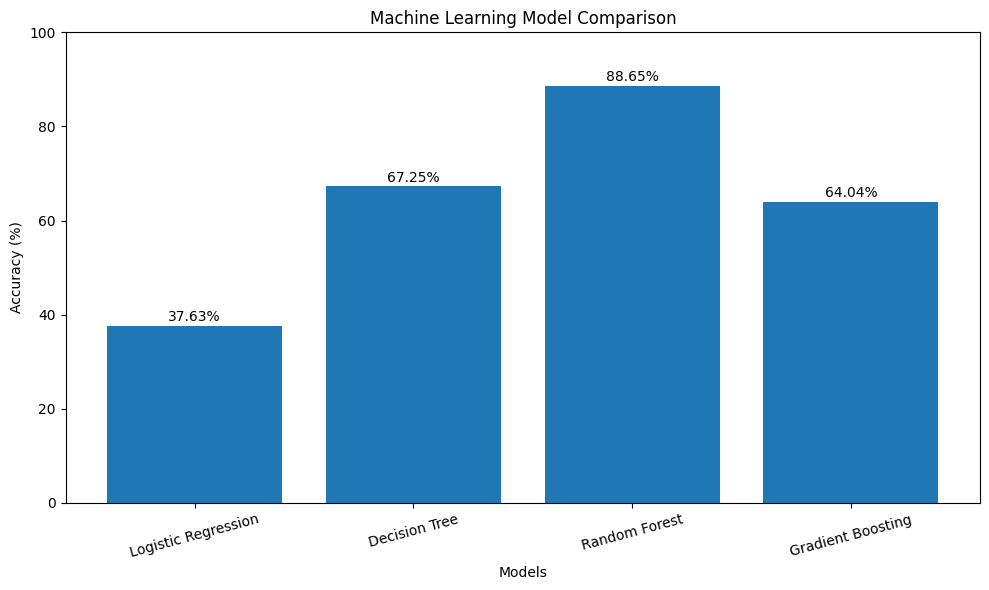

In [51]:
plt.figure(figsize=(10,6))

model_names = list(results.keys())

accuracies = [
    results[m]*100
    for m in model_names
]

bars = plt.bar(
    model_names,
    accuracies
)

plt.title('Machine Learning Model Comparison')

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

plt.ylim(0,100)

for bar, acc in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        f'{acc:.2f}%',
        ha='center'
    )

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()



In [52]:
joblib.dump(
    best_model,
    'traffic_best_model.pkl'
)

joblib.dump(
    le_location,
    'location_encoder.pkl'
)

joblib.dump(
    le_weather,
    'weather_encoder.pkl'
)

joblib.dump(
    le_target,
    'target_encoder.pkl'
)

print("\nModel Saved Successfully")




Model Saved Successfully


REAL-TIME PREDICTION FUNCTION

In [53]:
def predict_congestion(
    location,
    weather,
    vehicle_count,
    average_speed,
    hour,
    day_of_week,
    month
):

    # Encode input
    location_code = le_location.transform(
        [location]
    )[0]

    weather_code = le_weather.transform(
        [weather]
    )[0]

    # Create feature vector
    features = np.array([[
        location_code,
        weather_code,
        vehicle_count,
        average_speed,
        hour,
        day_of_week,
        1 if day_of_week >= 5 else 0,
        month
    ]])

    # Prediction
    prediction = best_model.predict(features)

    result = le_target.inverse_transform(
        prediction
    )[0]

    return result


DEMO PREDICTION

In [65]:

prediction = predict_congestion(

    location='Baneshwor',

    weather='Rain',

    vehicle_count=1200,

    average_speed=18,

    hour=8,

    day_of_week=2,

    month=5
)

print(
    f"\nPredicted Congestion Level: {prediction}"
)
#app ss is in github with high,low,meduim prediction with differnt waether,vehicle count,speed etc.


Predicted Congestion Level: Low
